In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install video-diffusion-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 37.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [5]:
!pip install torchmetrics
from torchmetrics.functional import structural_similarity_index_measure as ssim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 25.9 MB/s eta 0:00:00


In [6]:
from torchmetrics.functional import mean_absolute_error as mae
import torchvision
import math

def psnr(pred, target, max_val=1.0):
    mse = torch.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * torch.log10(max_val / torch.sqrt(mse))


In [7]:
import torch.nn.functional as F


In [8]:
# Path to your new conditional diffusion model checkpoint
# CKPT_PATH = '/content/drive/MyDrive/Model training/cloud_motion_diffusion_full_3D_UNet_final.pth'

# Folder where your .h5 files live
DATA_FOLDER = '/content/drive/MyDrive/3DS_resized_96_1/'

import glob
all_h5_paths = sorted(glob.glob(DATA_FOLDER + '*.h5'))
print(f"Found {len(all_h5_paths)} files")


Found 96 files


In [9]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# List of spectral bands to load
band_list = ['IMG_VIS', 'IMG_WV', 'IMG_TIR1', 'IMG_TIR2', 'IMG_MIR', 'IMG_SWIR']

# Function to load 1 sample = sequence of 8 timesteps (frames)
def load_sequence(h5_file_paths, bands, sequence_length=8):
    sequence = []
    for path in h5_file_paths[:sequence_length]:
        with h5py.File(path, 'r') as f:
            frame = [f[band][0] for band in bands]  # (6, 128, 128)
            sequence.append(np.stack(frame))  # (6, 128, 128)
    return torch.tensor(np.stack(sequence), dtype=torch.float32)  # (8, 6, 128, 128)

# PyTorch Dataset class
class CloudMotionDataset(Dataset):


    def __init__(self, h5_file_paths, bands, sequence_length):
        self.paths = h5_file_paths
        self.bands = bands
        self.seq_len = sequence_length

        self.valid_start_indices = list(range(0, len(h5_file_paths) - sequence_length + 1))
        self.starts = list(range(len(h5_file_paths) - sequence_length + 1))  # ✅ FIXED variable names


    def __len__(self):
        return len(self.valid_start_indices)


    def __getitem__(self, i):
        sp = self.starts[i]
        x = load_sequence(self.paths[sp:sp+self.seq_len], self.bands, self.seq_len)  # (8,6,128,128)

        # Normalize each band independently to [–1, 1]
        x_reshaped = x.permute(1, 0, 2, 3).reshape(6, -1)  # (6, N)
        mins = x_reshaped.min(dim=1, keepdim=True)[0]
        maxs = x_reshaped.max(dim=1, keepdim=True)[0]
        norm = (x_reshaped - mins) / (maxs - mins + 1e-5)
        norm = norm * 2 - 1
        x_norm = norm.view(6, self.seq_len, 128, 128).permute(1, 0, 2, 3)  # (8,6,128,128)

        # Conditional setup: split into 6 input + 2 output
        cond = x_norm[:6]     # (6, 6, 128, 128)
        target = x_norm[6:]   # (2, 6, 128, 128)

        return cond, target




# Create dataset instance
dataset = CloudMotionDataset(all_h5_paths, band_list, sequence_length=8)  # ✅ Fixed



In [10]:
import torch
import torch.nn as nn
from torchmetrics.functional import structural_similarity_index_measure as ssim


class ResidualBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(ResidualBlock3D, self).__init__()
        self.same_channels = in_channels == out_channels

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size, padding=padding)

        self.residual = nn.Identity() if self.same_channels else nn.Conv3d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        residual = self.residual(x)
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        return self.relu(out + residual)


In [11]:
class Encoder3D(nn.Module):
    def __init__(self, in_channels, base_channels=64, time_embed_dim=128):
        super(Encoder3D, self).__init__()

        self.enc1 = nn.Sequential(
            ResidualBlock3D(in_channels, base_channels),
            ResidualBlock3D(base_channels, base_channels)
        )

        self.down1 = nn.Conv3d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.enc2 = nn.Sequential(
            ResidualBlock3D(base_channels * 2, base_channels * 2),
            ResidualBlock3D(base_channels * 2, base_channels * 2)
        )

        self.down2 = nn.Conv3d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.enc3 = nn.Sequential(
            ResidualBlock3D(base_channels * 4, base_channels * 4),
            ResidualBlock3D(base_channels * 4, base_channels * 4)
        )

        # 🔌 Add timestep projection layers
        self.time_proj1 = nn.Linear(time_embed_dim, in_channels)  # project to 6 channels, not 64
        self.time_proj2 = nn.Linear(time_embed_dim, base_channels * 2)
        self.time_proj3 = nn.Linear(time_embed_dim, base_channels * 4)

    def forward(self, x, time_emb):
        # time_emb: (B, time_embed_dim)

        B, _, D, H, W = x.shape  # Batch, Channels, Depth, Height, Width

        # Project time embedding and reshape for broadcasting
        t1 = self.time_proj1(time_emb).view(B, -1, 1, 1, 1)
        t2 = self.time_proj2(time_emb).view(B, -1, 1, 1, 1)
        t3 = self.time_proj3(time_emb).view(B, -1, 1, 1, 1)

        # Inject time embeddings into encoder blocks
        x1 = self.enc1(x + t1)
        x2 = self.enc2(self.down1(x1) + t2)
        x3 = self.enc3(self.down2(x2) + t3)

        return x1, x2, x3


In [12]:
class Bottleneck3D(nn.Module):
    def __init__(self, in_channels, time_embed_dim=128):
        super(Bottleneck3D, self).__init__()
        self.time_proj = nn.Linear(time_embed_dim, in_channels)

        self.block = nn.Sequential(
            ResidualBlock3D(in_channels, in_channels),
            ResidualBlock3D(in_channels, in_channels)
        )

    def forward(self, x, time_emb):
        # time_emb shape: (B, time_embed_dim)
        B = x.shape[0]
        t = self.time_proj(time_emb).view(B, -1, 1, 1, 1)
        x = x + t
        return self.block(x)


In [13]:
class Decoder3D(nn.Module):
    def __init__(self, base_channels=64, out_channels=6, time_embed_dim=128):
        super(Decoder3D, self).__init__()

        # Upsample from bottleneck: 4*BC → 2*BC
        self.up1 = nn.ConvTranspose3d(base_channels * 4, base_channels * 2,
                                      kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.Sequential(
            ResidualBlock3D(base_channels * 4, base_channels * 2),
            ResidualBlock3D(base_channels * 2, base_channels * 2)
        )

        # Upsample from second block: 2*BC → BC
        self.up2 = nn.ConvTranspose3d(base_channels * 2, base_channels,
                                      kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(
            ResidualBlock3D(base_channels * 2, base_channels),
            ResidualBlock3D(base_channels, base_channels)
        )

        # Final 1×1 convolution to project to output channels
        self.out_conv = nn.Conv3d(base_channels, out_channels, kernel_size=1)

        # 🔌 Timestep embedding projection layers:
        #   t1 injects into 4*BC feature map (after concat of up1 + x2)
        self.time_proj1 = nn.Linear(time_embed_dim, base_channels * 4)
        #   t2 injects into 2*BC feature map (after concat of up2 + x1)
        self.time_proj2 = nn.Linear(time_embed_dim, base_channels * 2)

    def forward(self, x3, x2, x1, time_emb):
        """
        x3: bottleneck output (B, 4*BC, D, H, W)
        x2: skip from encoder level 2 (B, 2*BC, D*2, H*2, W*2)
        x1: skip from encoder level 1 (B,   BC, D*4, H*4, W*4)
        time_emb: (B, time_embed_dim)
        """
        B = x3.shape[0]

        # Project timestep embeddings
        t1 = self.time_proj1(time_emb).view(B, -1, 1, 1, 1)  # (B, 256,1,1,1)
        t2 = self.time_proj2(time_emb).view(B, -1, 1, 1, 1)  # (B, 128,1,1,1)

        # First decoding stage
        x = self.up1(x3)                   # (B, 128, D*2, H*2, W*2)
        x = torch.cat([x, x2], dim=1)      # (B, 256, D*2, H*2, W*2)
        x = self.dec1(x + t1)              # inject t1 here

        # Second decoding stage
        x = self.up2(x)                    # (B,  64, D*4, H*4, W*4)
        x = torch.cat([x, x1], dim=1)      # (B, 128, D*4, H*4, W*4)
        x = self.dec2(x + t2)              # inject t2 here

        # Final output projection
        out = self.out_conv(x)             # (B, out_channels, D*4, H*4, W*4)
        return out


In [14]:
import math

def get_timestep_embedding(timesteps, embedding_dim):
    """
    From Fairseq and DDPM: Returns sinusoidal timestep embeddings.
    timesteps: Tensor of shape [batch_size] (ints or floats).
    embedding_dim: Size of each embedding vector.
    """
    half_dim = embedding_dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    emb = timesteps[:, None] * emb[None, :]  # (B, half_dim)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)  # (B, embedding_dim)
    if embedding_dim % 2 == 1:  # if odd, pad one more dim
        emb = F.pad(emb, (0, 1))
    return emb


In [15]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timesteps):
        """
        Create sinusoidal timestep embeddings (same as get_timestep_embedding).
        Input: timesteps (B,) — integer tensor
        Output: (B, embedding_dim)
        """
        half_dim = self.embedding_dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
        emb = timesteps[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        if self.embedding_dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


In [16]:
class UNet3D_Full(nn.Module):
    def __init__(self, time_steps=6, image_channels=6, base_channels=64, time_embed_dim=128):
        super(UNet3D_Full, self).__init__()

        self.encoder = Encoder3D(image_channels, base_channels)
        self.bottleneck = Bottleneck3D(base_channels * 4, time_embed_dim)
        self.decoder = Decoder3D(base_channels, out_channels=image_channels, time_embed_dim=time_embed_dim)

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_embed_dim),
            nn.Linear(time_embed_dim, time_embed_dim),
            nn.ReLU()
        )
        self.time_embed_dim = time_embed_dim

    def forward(self, x, t):
        # x: (B, C=6, T=8, H, W), t: scalar or tensor of shape (B,)
        time_emb = self.time_mlp(t)  # shape: (B, time_embed_dim)

        x1, x2, x3 = self.encoder(x, time_emb)
        bottleneck = self.bottleneck(x3, time_emb)
        out = self.decoder(bottleneck, x2, x1, time_emb)
        return out


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.functional import structural_similarity_index_measure as ssim
from torchmetrics.functional import mean_absolute_error as mae
import math

def psnr(pred, target, max_val=1.0):
    mse = torch.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * torch.log10(max_val / torch.sqrt(mse))


class GaussianDiffusion(nn.Module):
    def __init__(self, model, image_size, timesteps=1000, sampling_timesteps=250):
        super().__init__()
        self.model = model
        self.image_size = image_size
        self.timesteps = timesteps
        self.sampling_timesteps = sampling_timesteps
        self.loss_fn = nn.MSELoss()

    def forward(self, x, t=None):
        # x shape: (B, T, C, H, W) → model expects (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)  # (B, C, T, H, W)

        if t is None:
            t = torch.randint(0, self.timesteps, (x.shape[0],), device=x.device)

        pred = self.model(x, t)  # (B, C, T, H, W)

        # --- MSE ---
        mse_loss = self.loss_fn(pred, x)

        # --- SSIM ---
        B, C, T, H, W = x.shape
        ssim_loss = 0.0

        for t_idx in range(T):
            pred_t = pred[:, :, t_idx, :, :]   # (B, C, H, W)
            target_t = x[:, :, t_idx, :, :]    # (B, C, H, W)
            ssim_val = ssim(pred_t, target_t, data_range=1.0)
            ssim_loss += 1 - ssim_val  # convert SSIM to loss

        ssim_loss = ssim_loss / T

        # --- MAE & PSNR ---
        mae_val = mae(pred.contiguous(), x.contiguous())  # Fix .view() error
        psnr_val = psnr(pred, x)

        # --- Combine ---
        total_loss = mse_loss + 0.5 * ssim_loss
        return total_loss, mse_loss.detach(), ssim_loss.detach(), mae_val.detach(), psnr_val

    @torch.no_grad()
    def sample(self, cond, batch_size=1):
        B, T, C, H, W = cond.shape  # cond: (B, 6, C, H, W)

        x = torch.randn(batch_size, 2, C, H, W, device=cond.device)  # predict 2 future frames

        for step in range(self.sampling_timesteps):
            combined = torch.cat([cond, x], dim=1)        # (B, 8, C, H, W)
            combined = combined.permute(0, 2, 1, 3, 4)     # (B, C, T=8, H, W)

            t = torch.full((B,), step, device=cond.device, dtype=torch.long)
            x_pred = self.model(combined, t)              # (B, C, T=8, H, W)

            x = x_pred.permute(0, 2, 1, 3, 4)[:, 6:]       # keep only T7/T8

        return torch.cat([cond, x], dim=1)  # Final shape: (B, 8, C, H, W)


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = UNet3D_Full(
    time_steps=6,
    image_channels=6,
    base_channels=64
).to(device)

diffusion = GaussianDiffusion(
    model,
    image_size=128,
    timesteps=1000
).to(device)


In [19]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)

# Optimizer for the diffusion model
optimizer = torch.optim.Adam(diffusion.parameters(), lr=8e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
diffusion.to(device)


GaussianDiffusion(
  (model): UNet3D_Full(
    (encoder): Encoder3D(
      (enc1): Sequential(
        (0): ResidualBlock3D(
          (conv1): Conv3d(6, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (relu): ReLU(inplace=True)
          (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (residual): Conv3d(6, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1))
        )
        (1): ResidualBlock3D(
          (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (relu): ReLU(inplace=True)
          (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (residual): Identity()
        )
      )
      (down1): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
      (enc2): Sequential(
        (0): ResidualBlock3D(
          (conv1): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (relu

In [28]:
# === 🔁 Start fresh training with timestep embeddings ===

CKPT_PATH = "/content/drive/MyDrive/Model training/cloud_motion_diffusion_with_time_embed_new_loss_final.pth"

start_epoch = 0            # Start from scratch
end_epoch = start_epoch + 30  # Train for 30 epochs

print(f"🔁 Starting fresh training from epoch {start_epoch} to {end_epoch}")


🔁 Starting fresh training from epoch 0 to 30


Epoch 1/30: 100%|██████████| 45/45 [02:35<00:00,  3.47s/it]


✅ Epoch 1 | Loss: 0.6397 | MSE: 0.2197 | SSIM: 0.8401 | MAE: 0.3786 | PSNR: 7.22 dB


Epoch 2/30: 100%|██████████| 45/45 [00:47<00:00,  1.06s/it]


✅ Epoch 2 | Loss: 0.3555 | MSE: 0.0638 | SSIM: 0.5834 | MAE: 0.1963 | PSNR: 12.08 dB


Epoch 3/30: 100%|██████████| 45/45 [00:54<00:00,  1.21s/it]


...

✅ Epoch 8 | Loss: 0.1378 | MSE: 0.0144 | SSIM: 0.2469 | MAE: 0.0880 | PSNR: 18.60 dB


Epoch 9/30: 100%|██████████| 45/45 [00:54<00:00,  1.21s/it]


✅ Epoch 9 | Loss: 0.1218 | MSE: 0.0106 | SSIM: 0.2224 | MAE: 0.0773 | PSNR: 19.85 dB


Epoch 10/30: 100%|██████████| 45/45 [00:53<00:00,  1.18s/it]


✅ Epoch 10 | Loss: 0.1117 | MSE: 0.0096 | SSIM: 0.2041 | MAE: 0.0735 | PSNR: 20.35 dB
🌀 Generating sample @ epoch 10


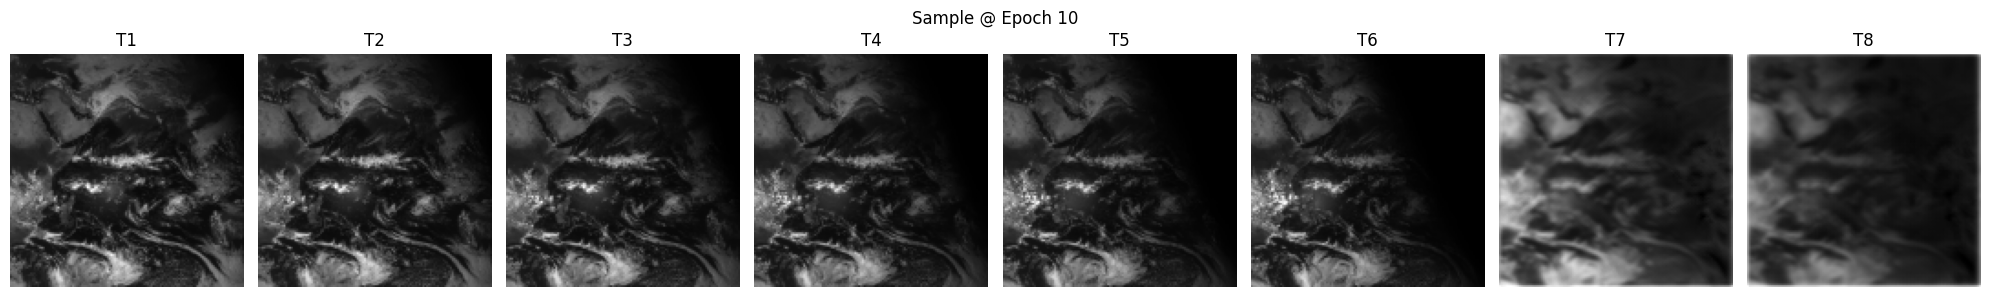

Epoch 11/30: 100%|██████████| 45/45 [00:47<00:00,  1.05s/it]


✅ Epoch 11 | Loss: 0.1042 | MSE: 0.0090 | SSIM: 0.1904 | MAE: 0.0710 | PSNR: 20.65 dB


Epoch 12/30: 100%|██████████| 45/45 [00:55<00:00,  1.23s/it]


✅ Epoch 12 | Loss: 0.1145 | MSE: 0.0103 | SSIM: 0.2082 | MAE: 0.0783 | PSNR: 20.03 dB


Epoch 13/30: 100%|██████████| 45/45 [00:54<00:00,  1.22s/it]


...

✅ Epoch 18 | Loss: 0.0709 | MSE: 0.0051 | SSIM: 0.1317 | MAE: 0.0525 | PSNR: 23.08 dB


Epoch 19/30: 100%|██████████| 45/45 [00:55<00:00,  1.23s/it]


✅ Epoch 19 | Loss: 0.0742 | MSE: 0.0055 | SSIM: 0.1375 | MAE: 0.0549 | PSNR: 22.76 dB


Epoch 20/30: 100%|██████████| 45/45 [00:54<00:00,  1.21s/it]


✅ Epoch 20 | Loss: 0.0683 | MSE: 0.0047 | SSIM: 0.1271 | MAE: 0.0510 | PSNR: 23.40 dB
🌀 Generating sample @ epoch 20


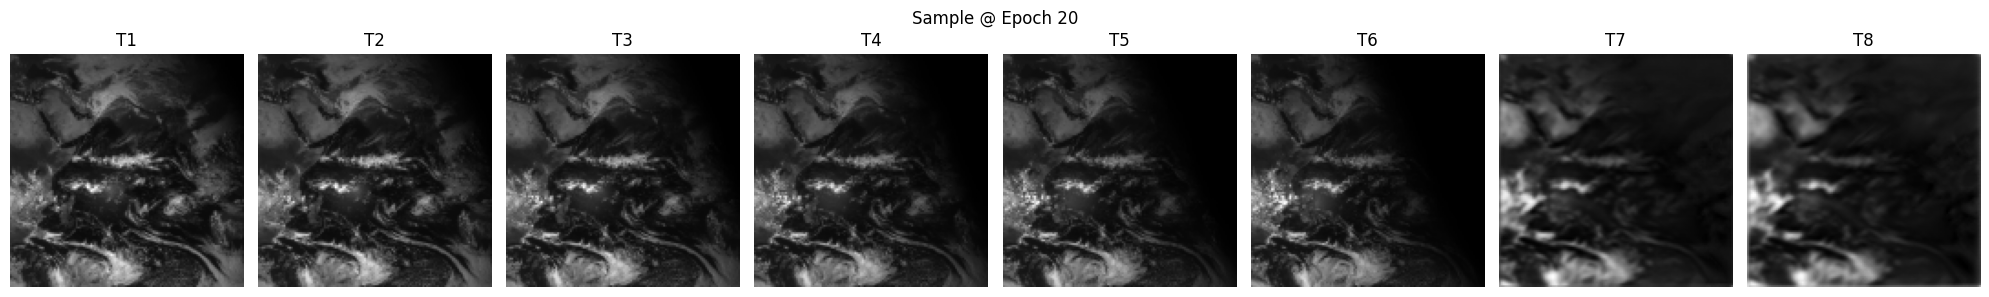

Epoch 21/30: 100%|██████████| 45/45 [00:47<00:00,  1.05s/it]


✅ Epoch 21 | Loss: 0.0693 | MSE: 0.0048 | SSIM: 0.1291 | MAE: 0.0521 | PSNR: 23.37 dB


Epoch 22/30: 100%|██████████| 45/45 [00:56<00:00,  1.26s/it]


✅ Epoch 22 | Loss: 0.0671 | MSE: 0.0047 | SSIM: 0.1248 | MAE: 0.0524 | PSNR: 23.45 dB


Epoch 23/30: 100%|██████████| 45/45 [00:54<00:00,  1.21s/it]


...

✅ Epoch 28 | Loss: 0.0534 | MSE: 0.0033 | SSIM: 0.1002 | MAE: 0.0430 | PSNR: 25.00 dB


Epoch 29/30: 100%|██████████| 45/45 [00:52<00:00,  1.17s/it]


✅ Epoch 29 | Loss: 0.0519 | MSE: 0.0032 | SSIM: 0.0974 | MAE: 0.0425 | PSNR: 25.07 dB


Epoch 30/30: 100%|██████████| 45/45 [00:52<00:00,  1.17s/it]


✅ Epoch 30 | Loss: 0.0537 | MSE: 0.0033 | SSIM: 0.1007 | MAE: 0.0443 | PSNR: 24.88 dB
🌀 Generating sample @ epoch 30


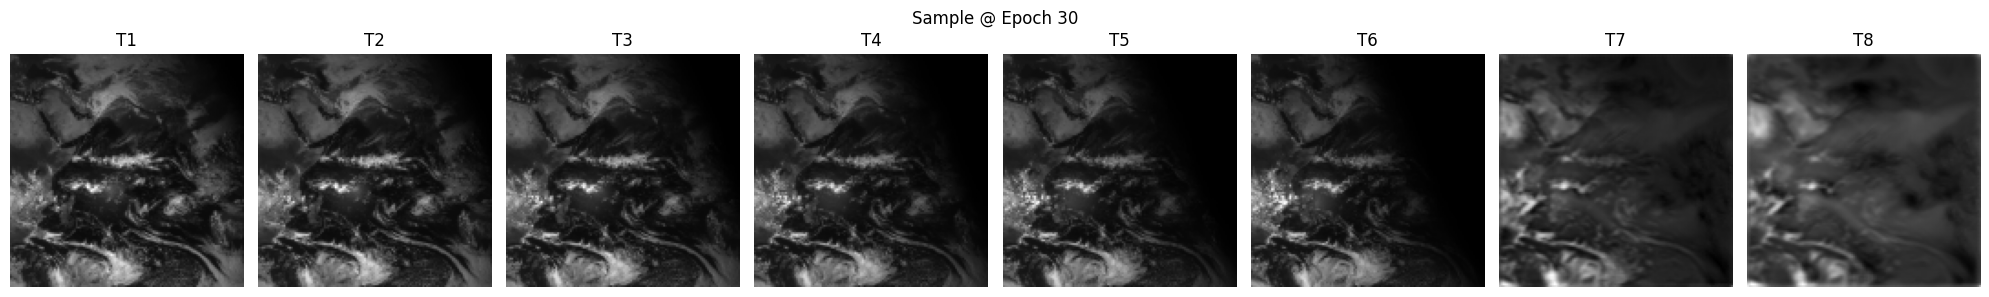

✅ Finished training and saved final checkpoint.


In [29]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchmetrics.functional import structural_similarity_index_measure as ssim
from torchmetrics.functional import mean_absolute_error as mae
import math

# === Hyperparameters ===
accum_steps  = 4
num_epochs   = end_epoch
CKPT_PATH    = "/content/drive/MyDrive/Model training/cloud_motion_diffusion_with_time_embed_new_loss_final.pth"

# Select a fixed cond for visualization
fixed_cond = next(iter(dataloader))[0][:1].to(device)

for epoch in range(start_epoch, end_epoch):
    model.train()
    diffusion.train()

    running_mse   = 0.0
    running_ssim  = 0.0
    running_mae   = 0.0
    running_psnr  = 0.0
    running_total = 0.0

    optimizer.zero_grad()

    for i, (cond, target) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        cond   = cond.to(device)
        target = target.to(device)
        full_seq = torch.cat([cond, target], dim=1)  # (B, 8, C, H, W)
        t = torch.randint(0, diffusion.timesteps, (full_seq.shape[0],), device=device)

        # Get all losses from diffusion
        total_loss, loss_mse, loss_ssim, loss_mae, loss_psnr = diffusion(full_seq, t)
        loss = total_loss / accum_steps

        loss.backward()
        running_mse   += loss_mse.item()
        running_ssim  += loss_ssim.item()
        running_mae   += loss_mae.item()
        running_psnr  += loss_psnr if isinstance(loss_psnr, float) else loss_psnr.item()
        running_total += total_loss.item()

        if (i + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        torch.cuda.empty_cache()

    if (i + 1) % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    # Compute epoch-wise averages
    avg_total = running_total / len(dataloader)
    avg_mse   = running_mse / len(dataloader)
    avg_ssim  = running_ssim / len(dataloader)
    avg_mae   = running_mae / len(dataloader)
    avg_psnr  = running_psnr / len(dataloader)

    print(f"✅ Epoch {epoch+1} | Loss: {avg_total:.4f} | MSE: {avg_mse:.4f} | SSIM: {avg_ssim:.4f} | MAE: {avg_mae:.4f} | PSNR: {avg_psnr:.2f} dB")

    # Save checkpoint
    torch.save({
        'model_state_dict':       model.state_dict(),
        'diffusion_state_dict':   diffusion.state_dict(),
        'optimizer_state_dict':   optimizer.state_dict(),
        'epoch':                  epoch + 1,
    }, CKPT_PATH)

    # Visualize every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"🌀 Generating sample @ epoch {epoch+1}")
        with torch.no_grad():
            sample = diffusion.sample(cond=fixed_cond, batch_size=1).cpu()
            sample = sample.permute(0, 2, 1, 3, 4)  # (B, C, T, H, W)
            frames = sample[0, 0]  # Band 0 across time steps → (T=8, H, W)

            fig, axes = plt.subplots(1, 8, figsize=(20, 3))
            for t in range(8):
                axes[t].imshow(frames[t], cmap='gray')
                axes[t].axis('off')
                axes[t].set_title(f"T{t+1}")
            plt.suptitle(f"Sample @ Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()

# Final save
torch.save({
    'model_state_dict':       model.state_dict(),
    'diffusion_state_dict':   diffusion.state_dict(),
    'optimizer_state_dict':   optimizer.state_dict(),
    'epoch':                  end_epoch,
}, "/content/drive/MyDrive/Model training/cloud_motion_diffusion_with_time_embed_new_loss_final.pth")

print("✅ Finished training and saved final checkpoint.")
